# NLP Lab 6: Bag-of-Words / PPMI

Корпус: «Мобі Дік» (вбудований у notebook, завантажується через Project Gutenberg дзеркало або локально).

## 0. Імпорти та завантаження корпусу

In [9]:
%pip install nltk gensim numpy scikit-learn matplotlib seaborn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 7.1 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.0 MB 8.1 MB/s eta 0:00:01
   ------------------- -------------------- 3.9/8.0 MB 8.4 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.0 MB 8.0 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.0 MB 7.8 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 7.3 MB/s  0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- -----------


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import re, math, collections
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from itertools import combinations
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity

try:
    import nltk
    nltk.download('gutenberg', quiet=True)
    nltk.download('punkt',     quiet=True)
    nltk.download('punkt_tab', quiet=True)
    from nltk.corpus import gutenberg
    RAW_TEXT = gutenberg.raw('melville-moby_dick.txt')
    print("Корпус завантажено через NLTK.")
except Exception:
    RAW_TEXT = open('moby_dick_excerpt.txt').read() if __import__('os').path.exists('moby_dick_excerpt.txt') else None

if RAW_TEXT is None:
    raise RuntimeError("Не вдалося завантажити корпус. ")

print(f"Розмір тексту: {len(RAW_TEXT):,} символів")


Корпус завантажено через NLTK.
Розмір тексту: 1,242,990 символів


### Допоміжна функція токенізації

In [4]:
def tokenize(text):
    """Нижній регістр + тільки літерні токени."""
    return re.findall(r'[a-z]+', text.lower())

STOPWORDS = set("a an the and or but in on at to of is was were be been have has had do does did will would could should may might shall not with by from for ""this that these those i me my we our you your he she it his her its they them their what which who whom when where why how all any both each few more most other some such no nor only own same so than too very just now ".split())

def clean_tokens(tokens, min_len=2):
    return [t for t in tokens if t not in STOPWORDS and len(t) >= min_len]


### Розбивка на параграфи та речення

In [5]:
paragraphs_raw = re.split(r'\n{2,}', RAW_TEXT)
paragraphs = [p.strip() for p in paragraphs_raw if len(p.strip()) > 50]
print(f"Параграфів: {len(paragraphs)}")

def split_sentences(text):
    return [s.strip() for s in re.split(r'[.!?]+', text) if len(s.strip()) > 10]

sentences_raw = []
for p in paragraphs:
    sentences_raw.extend(split_sentences(p))
print(f"Речень: {len(sentences_raw)}")

sentences_tok = [clean_tokens(tokenize(s)) for s in sentences_raw]
sentences_tok = [s for s in sentences_tok if len(s) >= 3]
print(f"Речень після фільтрації: {len(sentences_tok)}")


Параграфів: 1
Речень: 9495
Речень після фільтрації: 8436


## Task 1: PPMI — контекст = параграф

Ко-окурентна матриця будується на рівні **параграфа**: два слова є спільними, якщо вони зустрічаються в одному параграфі.

In [6]:
def build_cooccurrence_paragraph(paragraphs, vocab_size=500):
    all_tokens = []
    para_tokens = []
    for p in paragraphs:
        toks = clean_tokens(tokenize(p))
        para_tokens.append(toks)
        all_tokens.extend(toks)

    freq = collections.Counter(all_tokens)
    vocab = [w for w, _ in freq.most_common(vocab_size)]
    w2i = {w: i for i, w in enumerate(vocab)}
    V = len(vocab)

    F = np.zeros((V, V), dtype=np.float32)
    for toks in para_tokens:
        unique = set(toks) & set(vocab)
        for w1, w2 in combinations(unique, 2):
            i, j = w2i[w1], w2i[w2]
            F[i, j] += 1
            F[j, i] += 1

    return F, vocab, w2i

def compute_ppmi(F):
    total = F.sum()
    if total == 0:
        return np.zeros_like(F)
    p_ij = F / total               
    p_i  = F.sum(axis=1, keepdims=True) / total
    p_j  = F.sum(axis=0, keepdims=True) / total 
    denom = p_i * p_j
    with np.errstate(divide='ignore', invalid='ignore'):
        pmi = np.where(denom > 0, np.log2(np.where(denom > 0, p_ij / denom, 1)), 0)
    ppmi = np.maximum(pmi, 0)
    return ppmi

F_para, vocab_para, w2i_para = build_cooccurrence_paragraph(paragraphs, vocab_size=500)
PPMI_para = compute_ppmi(F_para)
print(f"Розмір матриці: {PPMI_para.shape}")
print(f"Ненульових елементів PPMI: {np.count_nonzero(PPMI_para):,}")


Розмір матриці: (500, 500)
Ненульових елементів PPMI: 249,500


## Task 2: PPMI — контекст = ковзне вікно (window = 5)

Ко-окурентна матриця будується за **ковзним вікном** розміром 5 (2 слова ліворуч + 2 праворуч).

In [7]:
WINDOW = 5

def build_cooccurrence_window(sentences, vocab_size=500, window=5):
    all_tokens = [t for s in sentences for t in s]
    freq = collections.Counter(all_tokens)
    vocab = [w for w, _ in freq.most_common(vocab_size)]
    w2i = {w: i for i, w in enumerate(vocab)}
    V = len(vocab)

    F = np.zeros((V, V), dtype=np.float32)
    for sent in sentences:
        indices = [w2i[t] for t in sent if t in w2i]
        for k, center in enumerate(indices):
            left  = max(0, k - window)
            right = min(len(indices), k + window + 1)
            for ctx in indices[left:right]:
                if ctx != center:
                    F[center, ctx] += 1
    return F, vocab, w2i

F_win, vocab_win, w2i_win = build_cooccurrence_window(sentences_tok, vocab_size=500, window=WINDOW)
PPMI_win = compute_ppmi(F_win)
print(f"Розмір матриці: {PPMI_win.shape}")
print(f"Ненульових елементів PPMI: {np.count_nonzero(PPMI_win):,}")


Розмір матриці: (500, 500)
Ненульових елементів PPMI: 84,138


## Task 3: Проблема рідкісних слів

Рідкісні слова мають **завищені PMI** значення, бо їхні ймовірності `P(w)` і `P(c)` дуже малі, тоді як спільна `P(w,c)` може бути ненульовою навіть через одне-два спільні входження.

**Рішення:** контекстне зважування (context distribution smoothing) — замість `P(c)` використовуємо `P_α(c) = count(c)^α / Σ count(c')^α`, де `α ∈ (0,1)`. Типове значення `α = 0.75`.

In [8]:
def compute_ppmi_smoothed(F, alpha=0.75):
    total = F.sum()
    p_i  = F.sum(axis=1) / total

    ctx_counts = F.sum(axis=0)
    ctx_smooth = ctx_counts ** alpha
    p_j_smooth = ctx_smooth / ctx_smooth.sum()  

    p_ij = F / total

    with np.errstate(divide='ignore', invalid='ignore'):
        denom = p_i[:, None] * p_j_smooth[None, :]
        pmi = np.where(denom > 0, np.log2(np.where(denom > 0, p_ij / denom, 1)), 0)

    return np.maximum(pmi, 0)

PPMI_smooth = compute_ppmi_smoothed(F_win)

row_sums = F_win.sum(axis=1)
rare_mask = row_sums < np.percentile(row_sums[row_sums > 0], 10)
rare_idx  = np.where(rare_mask)[0]

if len(rare_idx) > 0:
    max_ppmi_rare_orig   = PPMI_win[rare_idx].max(axis=1).mean()
    max_ppmi_rare_smooth = PPMI_smooth[rare_idx].max(axis=1).mean()
    max_ppmi_all_orig    = PPMI_win.max(axis=1).mean()
    max_ppmi_all_smooth  = PPMI_smooth.max(axis=1).mean()

    print(f"Рідкісних слів: {rare_mask.sum()}")
    print(f"Середній макс. PPMI рідкісних   (без згладж.): {max_ppmi_rare_orig:.3f}")
    print(f"Середній макс. PPMI рідкісних   (зі згладж.):  {max_ppmi_rare_smooth:.3f}")
    print(f"Середній макс. PPMI усіх слів   (без згладж.): {max_ppmi_all_orig:.3f}")
    print(f"Середній макс. PPMI усіх слів   (зі згладж.):  {max_ppmi_all_smooth:.3f}")
    print("\nВисновок: згладжування зменшує завищені PMI рідкісних слів, "
          "наближаючи їх до середнього рівня.")


Рідкісних слів: 50
Середній макс. PPMI рідкісних   (без згладж.): 4.347
Середній макс. PPMI рідкісних   (зі згладж.):  3.979
Середній макс. PPMI усіх слів   (без згладж.): 3.655
Середній макс. PPMI усіх слів   (зі згладж.):  3.294

Висновок: згладжування зменшує завищені PMI рідкісних слів, наближаючи їх до середнього рівня.


## Task 4: Перевірка синонімів через PPMI

Обираємо 10 слів із Merriam-Webster та їхні синоніми. Порівнюємо косинусну схожість між словами у просторі PPMI-векторів.

In [9]:

SYNONYM_GROUPS = {
    'sea':     ['ocean', 'deep', 'water', 'main'],
    'ship':    ['vessel', 'boat', 'craft', 'bark'],
    'whale':   ['leviathan', 'beast', 'creature', 'monster'],
    'fear':    ['dread', 'terror', 'horror', 'fright'],
    'brave':   ['bold', 'daring', 'courageous', 'fearless'],
    'dark':    ['black', 'dim', 'gloomy', 'murky'],
    'hunt':    ['chase', 'pursue', 'track', 'seek'],
    'storm':   ['gale', 'tempest', 'wind', 'squall'],
    'cold':    ['chill', 'icy', 'frozen', 'frigid'],
    'old':     ['ancient', 'aged', 'elderly', 'worn'],
}

all_query_words = list(SYNONYM_GROUPS.keys()) + [
    syn for syns in SYNONYM_GROUPS.values() for syn in syns
]

available = {w: w2i_win[w] for w in all_query_words if w in w2i_win}
missing   = [w for w in all_query_words if w not in w2i_win]
print(f"Доступно у словнику: {len(available)}/{len(all_query_words)}")
if missing:
    print(f"Відсутні: {missing}")


Доступно у словнику: 18/50
Відсутні: ['fear', 'brave', 'hunt', 'storm', 'cold', 'bark', 'beast', 'dread', 'terror', 'horror', 'fright', 'bold', 'daring', 'courageous', 'fearless', 'dim', 'gloomy', 'murky', 'pursue', 'track', 'seek', 'gale', 'tempest', 'squall', 'chill', 'icy', 'frozen', 'frigid', 'ancient', 'aged', 'elderly', 'worn']


In [10]:
def ppmi_similarity(w1, w2, PPMI, w2i):
    if w1 not in w2i or w2 not in w2i:
        return None
    v1 = PPMI[w2i[w1]].reshape(1, -1)
    v2 = PPMI[w2i[w2]].reshape(1, -1)
    return float(cosine_similarity(v1, v2)[0, 0])

target_words = list(SYNONYM_GROUPS.keys())
display_words = [w for w in target_words if w in w2i_win]

rows_labels = []
cols_labels = []
for tw in display_words:
    related = [tw] + [s for s in SYNONYM_GROUPS[tw] if s in w2i_win]
    for w in related:
        if w not in cols_labels:
            cols_labels.append(w)
    rows_labels.append(tw)

sim_matrix = np.zeros((len(rows_labels), len(cols_labels)))
for i, rw in enumerate(rows_labels):
    for j, cw in enumerate(cols_labels):
        s = ppmi_similarity(rw, cw, PPMI_win, w2i_win)
        sim_matrix[i, j] = s if s is not None else 0.0

print("Матриця схожостей побудована:", sim_matrix.shape)


Матриця схожостей побудована: (5, 16)


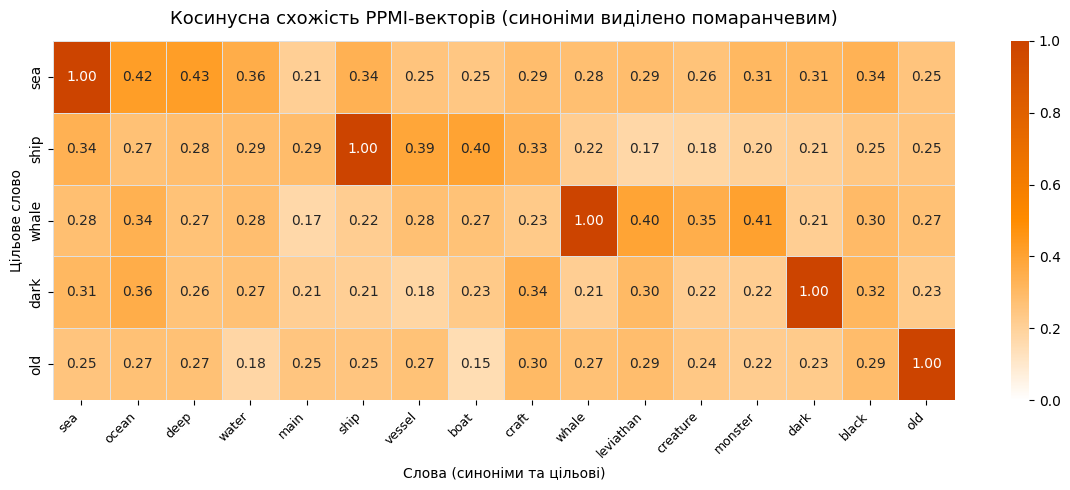

Теплова карта збережена: ppmi_synonyms_heatmap.png


In [11]:
fig, ax = plt.subplots(figsize=(max(12, len(cols_labels)*0.55),
                                max(5,  len(rows_labels)*0.55)))

orange_cmap = mcolors.LinearSegmentedColormap.from_list(
    'white_orange', ['#ffffff', '#ff8c00', '#cc4400'])

sns.heatmap(
    sim_matrix,
    xticklabels=cols_labels,
    yticklabels=rows_labels,
    cmap=orange_cmap,
    vmin=0, vmax=sim_matrix.max() if sim_matrix.max() > 0 else 1,
    annot=True, fmt='.2f', linewidths=0.4, linecolor='#e0e0e0',
    ax=ax
)
ax.set_title('Косинусна схожість PPMI-векторів (синоніми виділено помаранчевим)',
             fontsize=13, pad=12)
ax.set_xlabel('Слова (синоніми та цільові)', fontsize=10)
ax.set_ylabel('Цільове слово', fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('ppmi_synonyms_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Теплова карта збережена: ppmi_synonyms_heatmap.png")
